## Customer Churn Prediction

*Churn rate*, ou simplesmente *churn*, representa a taxa de evasão da sua base de clientes, ou seja, quantos deles deixam de comprar ou usar os seus produtos ou serviços em um determinado período. Este problema afeta diretamente a receita e o crescimento das organizações, pois representa a perda de clientes e de oportunidades de venda. Além disso, também impacta na satisfação e na fidelização dos consumidores, que são essenciais para a construção de uma marca forte e de confiança.

Ela é de extrema importância para a administração e sua análise ao longo do tempo pode mostrar que existe algum problema que deve ser atacado.

*Churn* também pode ser usado para identificar potenciais cancelamentos, com um tempo de antecedência, e promover ações direcionadas para tentar reter tais clientes. Essa métrica deve receber atenção pelo fato de que o Custo de Aquisição de Cliente (CAC) é normalmente mais alto que o custo para mantê-los. Ou seja, um alto valor para o *churn rate* é o que não desejamos.

Com base nessa informação o meu **objetivo** nesse projeto é que o modelo de Machine Learning apresente a melhor taxa de **True Positives** que são os clientes que irão cancelar e o modelo inferiu corretamente, podendo assim agir com antecedência.

## Importando os Dados

Os dados utilizados neste projeto foram originalmente disponibilizados na [plataforma de ensino da IBM Developer](https://developer.ibm.com/technologies/data-science/patterns/predict-customer-churn-using-watson-studio-and-jupyter-notebooks/#), e tratam de um problema típico de uma companhia de telecomunicações. O *dataset* completo pode ser encontrado [neste link](https://raw.githubusercontent.com/carlosfab/dsnp2/master/datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv).

Apesar de não haver informações explícitas disponíves, os nomes das colunas permitem um entendimento a respeito do problema.

In [1]:
# importa os pacotes necessários
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import scikitplot as skplt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from imblearn.pipeline import make_pipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.combine import SMOTETomek
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, roc_curve, auc, accuracy_score

# suprimi alguns warnings
from warnings import simplefilter
simplefilter(action='ignore', category=FutureWarning)

In [2]:
# versões dos pacotes
%reload_ext watermark
%watermark --iversions

seaborn   : 0.12.2
pandas    : 2.2.1
numpy     : 1.26.4
matplotlib: 3.8.3
scikitplot: 0.3.7
scipy     : 1.11.3



In [3]:
# importa os dados para um dataframe
DATA_PATH = "https://raw.githubusercontent.com/carlosfab/dsnp2/master/datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(DATA_PATH)

# dimensões do conjunto original
print("Dimensões do Conjunto Original: ", df.shape)

# criando o conjunto de teste
test = df.sample(frac=0.10, random_state=0)


# drop das linhas de teste
df = df.drop(test.index)

# verificando o conjunto
print("Dimensões do Conjunto de Treino: ", df.shape)
print("Dimensões do Conjunto de Teste: ", test.shape)

Dimensões do Conjunto Original:  (7043, 21)
Dimensões do Conjunto de Treino:  (6339, 21)
Dimensões do Conjunto de Teste:  (704, 21)


## Análise Exploratória

In [4]:
# verifica as 5 primeiras entradas
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Dicionário dos dados

Variáveis de cunho pessoal

* Variável `gender` categórica nominal. Indica o gênero do cliente.
* Variável `SeniorCitizen` categórica nominal. Indica se o cliente é uma pessoa idosa.
* Variável `Partner` categórica nominal. Indica se tem ou não um parceiro(a).
* Variável `Dependents` categórica nominal. Indica se tem ou não pessoais dependentes.
* Variável `tenure` numérica discreta. Indica quantos meses o cliente está/esteve com o plano, é um bom indicador de fidelidade

Variáveis sobre o plano contratado

* Variável `PhoneService` categórica nominal. Indica se o cliente tem contratado um serviço de celular.
* Variável `MultipleLines` categórica nominal. Indica se o cliente tem contratado múltiplas linhas.
* Variável `InternetService` categórica nominal. Indica se o cliente tem contratado um serviço de internet e qual o tipo.
* Variável `OnlineSecurity` categórica nominal. Indica se o cliente tem contratado um serviço de segurança.
* Variável `OnlineBackup` categórica nominal. Indica se o cliente tem contratado um serviço de Backup Online.
* Variável `DeviceProtection` categórica nominal. Indica se o cliente tem contratado um serviço de proteção ao dispositivo.
* Variável `TechSupport` categórica nominal. Indica se o cliente tem contratado um serviço de suporte técnico.
* Variável `StreamingTV` categórica nominal. Indica se o cliente tem contratado um serviço de streaming.
* Variável `StreamingMovies` categórica nominal. Indica se o cliente tem contratado um serviço de streaming.

Variáveis sobre o contrato

* Variável `Contract` categórica nominal. Indica o Tipo de contrato.
* Variável `PaperlessBilling` categórica nominal. Indica se a fatura é digital.
* Variável `PaymentMethod ` categórica nominal. Indica o método de pagamento.
* Variável `MonthlyCharges` variável numérica continua. Indica o valor da cobrança mensal do plano.
* Variável `TotalCharges` variável numérica continua. Indica o valor total das cobranças. +/-(Cobrança Mensal x a qtde de Meses (tenure)). Está com o tipo "object" e precisa de ajuste.

Variável Alvo

* Variável `Churn` indica se o cliente cancelou ou não o contrato.

In [5]:
# verificando se há valores ausentes ou duplicados
print('Valores ausentes: ', df.isnull().sum().any())
print('Valores duplicados: ', df.duplicated().sum().any())

Valores ausentes:  False
Valores duplicados:  False


Por se tratar de um *dataset* com muitas variáveis categórica é interessante entender a quantidade de valores únicos.

In [6]:
# verificando a quantidade de valores unicos
df.nunique()

customerID          6339
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1543
TotalCharges        5910
Churn                  2
dtype: int64

Com relação às variáveis categóricas, todas apresentam um padrão baixo de valores únicos. Com relação à variável `customerID` será removida, pois não ajudara no treinamento do modelo de Machine Learning.

### Data Cleaning

In [7]:
# Tentativa de converter o tipo de dado da variável de string para float
# pd.to_numeric(df['TotalCharges'])

Quando tentei converter os valores da variável `TotalCharges` identifiquei um erro. Alguns valores estão preenchidos com "espaço", um valor vazio (" "). Como demonstrado abaixo.

Assim, para conseguir converter adequadamente, criei uma função para lidar com essa exceção. Ao final, identifiquei que dados ausentes foram encontrados, e substitui pelo valor da mediana da coluna.

Abaixo, também já aproveitei e excluí a coluna `customerID`, que seria desnecessária ao longo deste projeto.

In [8]:
df.iloc[442]

customerID                         4472-LVYGI
gender                                 Female
SeniorCitizen                               0
Partner                                   Yes
Dependents                                Yes
tenure                                      0
PhoneService                               No
MultipleLines                No phone service
InternetService                           DSL
OnlineSecurity                            Yes
OnlineBackup                               No
DeviceProtection                          Yes
TechSupport                               Yes
StreamingTV                               Yes
StreamingMovies                            No
Contract                             Two year
PaperlessBilling                          Yes
PaymentMethod       Bank transfer (automatic)
MonthlyCharges                          52.55
TotalCharges                                 
Churn                                      No
Name: 488, dtype: object

In [9]:
def converter_str_float(entrada):
    """
    Converte um objeto do tipo string em float.

    # Arguments
        entrada: string, string da coluna TotalCharges.

    # Returns
        Valor convertido em float, caso permita a conversão.
        NaN, caso o valor não seja apropriado.
    """

    try:
        return float(entrada)
    except ValueError:
        return np.nan


# criar cópia do dataframe
df_clean = df.copy()


# remover coluna costumerID
df_clean = df_clean.drop("customerID", axis=1)

# converter as strings de TotalCharges para float
df_clean['TotalCharges'] = df_clean['TotalCharges'].apply(converter_str_float)

In [10]:
# verificar entradas ausentes
print(f"Dados ausentes em 'TotalCharges' (antes): {df_clean["TotalCharges"].isnull().sum()}")

Dados ausentes em 'TotalCharges' (antes): 9


In [11]:
# Explorando quais entradas específicas possuem valores ausentes
df_clean[df_clean.isnull().any(axis=1)]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No
6754,Male,0,No,Yes,0,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,NaN,No


Identifiquei um padrão nos dados, todos os valores ausentes possuem um contrato de 2 anos.

Irei substituir os valores ausentes da variável `TotalCharges` pela mediana dos valores da variável `Contract`.

In [12]:
median_values = df_clean.groupby('Contract')['TotalCharges'].median()
median_values

Contract
Month-to-month     688.500
One year          2658.800
Two year          3635.125
Name: TotalCharges, dtype: float64

In [13]:
# substituir os dados ausentes pelo valor da mediana
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(median_values.loc['Two year'])

In [14]:
# validando os resultado
df_clean.loc[[488, 753, 936, 1340, 3331, 3826, 4380, 6670, 6754]]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,3635.125,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,3635.125,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,3635.125,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,3635.125,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,3635.125,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,3635.125,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,3635.125,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,3635.125,No
6754,Male,0,No,Yes,0,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,3635.125,No


### Variáveis Numéricas

In [15]:
df_clean[['tenure',	'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,6339.000000,6339.000000,6339.000000
mean,32.412052,64.785431,2283.495587
std,24.561165,30.060197,2262.684683
min,0.000000,18.250000,18.850000
25%,9.000000,35.550000,407.775000
50%,29.000000,70.400000,1396.250000
75%,56.000000,89.850000,3783.200000
max,72.000000,118.750000,8684.800000


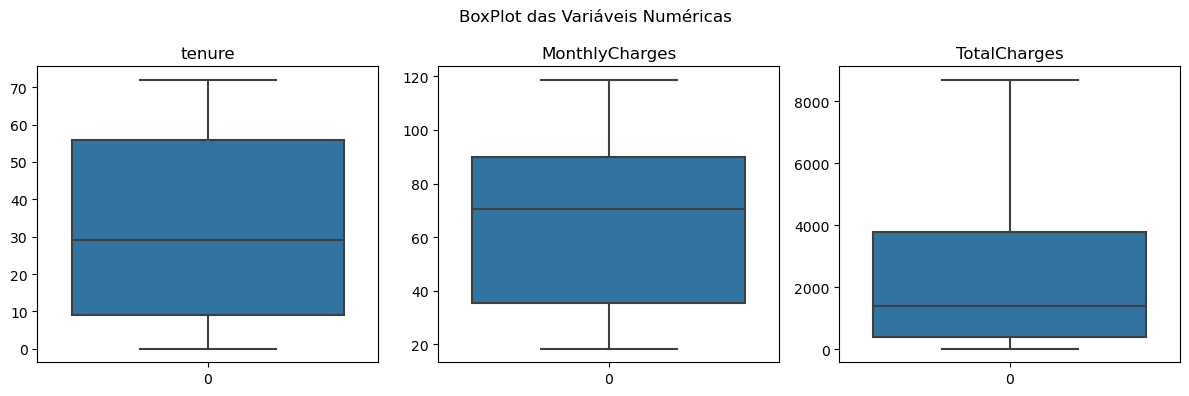

In [16]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))

fig.suptitle('BoxPlot das Variáveis Numéricas', fontsize= 12)

sns.boxplot(df_clean['tenure'], ax=ax[0]).set(title='tenure')
sns.boxplot(df_clean['MonthlyCharges'], ax=ax[1]).set(title='MonthlyCharges')
sns.boxplot(df_clean['TotalCharges'], ax=ax[2]).set(title='TotalCharges')

plt.tight_layout()

De acordo com métodos `describe` e `boxplot` não há indícios da presença de outliers.

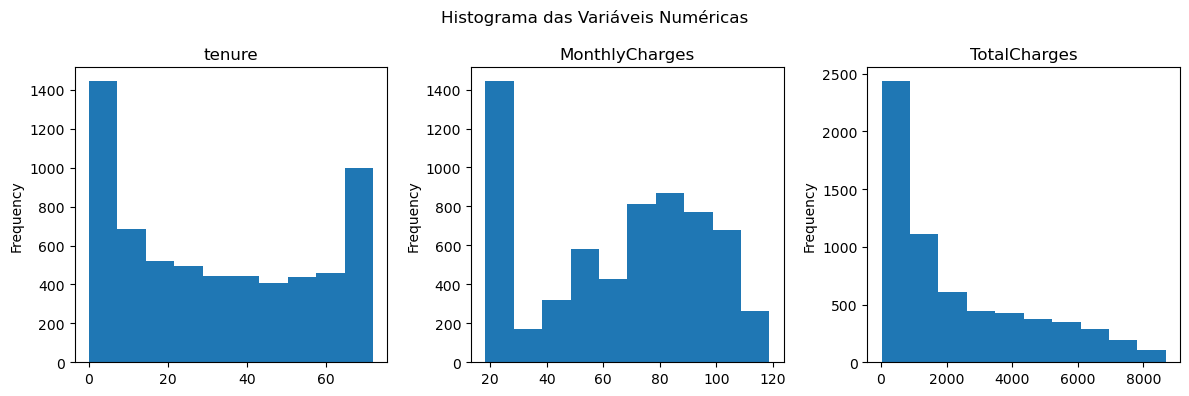

In [17]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))

fig.suptitle('Histograma das Variáveis Numéricas', fontsize= 12)

df_clean['tenure'].plot(kind='hist', ax=ax[0], title='tenure')
df_clean['MonthlyCharges'].plot(kind='hist', ax=ax[1], title='MonthlyCharges')
df_clean['TotalCharges'].plot(kind='hist', ax=ax[2], title='TotalCharges')

plt.tight_layout()

Skewness 

Se a variável de resposta tiver um numero de skew, o modelo será treinado num número muito maior de casas com preços moderados e terá menos probabilidade de prever com sucesso o preço das casas mais caras. O conceito é o mesmo de treinar um modelo em classes categóricas desequilibradas. Se os valores de uma *determinada variável independente* (característica) estiverem distorcidos (skew), dependendo do modelo, a assimetria pode violar as suposições do modelo (por exemplo, regressão logística) ou pode prejudicar a interpretação da importância da característica. Podemos determinar objetivamente se a variável está distorcida usando o teste de Shapiro-Wilks. Uma maneira mais conveniente de avaliar a assimetria é com o método “.skew” do pandas. Ele calcula o coeficiente de momento padronizado Fisher-Pearson para todas as colunas em um dataframe.

In [18]:
# verificando a skewness
print(df_clean['tenure'].skew())
print(df_clean['MonthlyCharges'].skew())
print(df_clean['TotalCharges'].skew())

0.23687556780519134
-0.22410999085033081
0.9613294562084637


In [19]:
df_clean['TotalCharges'] = np.log1p(df_clean['TotalCharges'])

Aplicando a transformação logarítmica na variável `TotalCharges` obtive uma melhora significativa no resultado do modelo nos dados de `teste`.

### Variáveis Categóricas

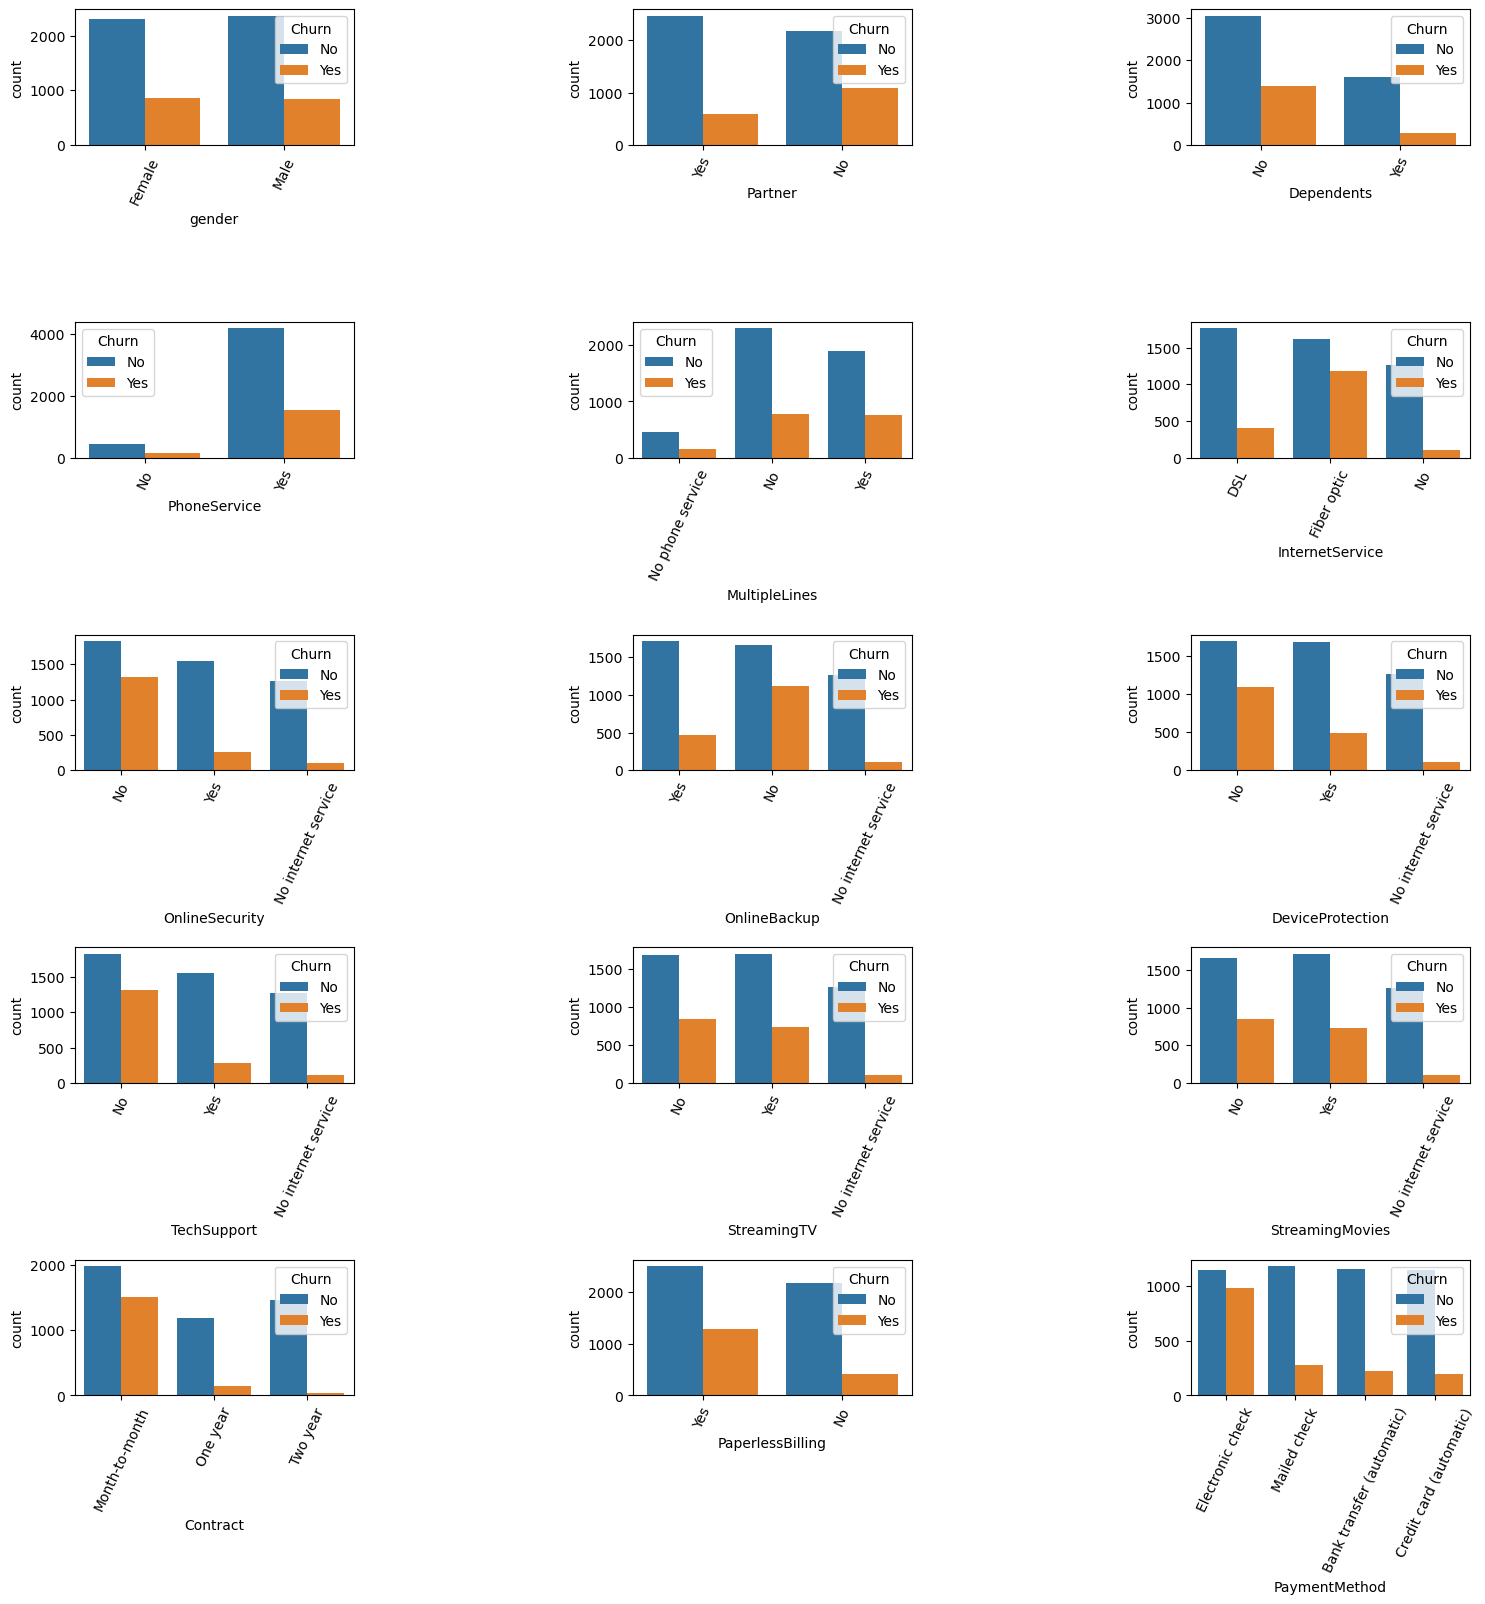

In [20]:
cat_cols = df_clean.select_dtypes(include='object').drop('Churn', axis=1).columns

fig, ax = plt.subplots(nrows=5, ncols=3, figsize=(18,18))
fig.subplots_adjust(hspace=1.3, wspace=1)

idx = 0
for col in cat_cols:
    idx += 1
    plt.subplot(5, 3, idx)
    plt.xticks(rotation=65)
    sns.countplot(data=df_clean, x=df_clean[col], hue=df_clean['Churn'])
        
plt.tight_layout
plt.show()

Algumas observações mais discrepantes:

* Clientes que possuem um serviço de segurança online ou não tem Serviço de internet `OnlineSecurity` possuem um baixo rate de Churn.
* Clientes com contratos de 1 ano ou 2 possuem um baixo rate de Churn. `Contract`
* Clientes que tem um método de pagamento que não seja por Eletronic check apresentam uma probabilidade menor de Churn. `PaymentMethod`

### Variável Target

Churn
No     4650
Yes    1689
Name: count, dtype: int64

O número de cancelamentos representam 26.64% do dataset.



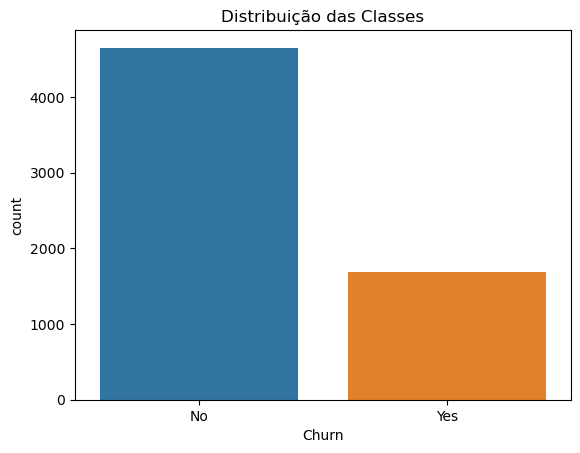

In [21]:
# verifica o balanceamento das classes
print(df_clean.Churn.value_counts())
print("\nO número de cancelamentos representam {:.2f}% do dataset.\n".format((df_clean[df_clean.Churn == 'Yes'].shape[0] / df_clean.shape[0]) * 100))

# plota um gráfico de barras para as Classes
fig, ax = plt.subplots()
sns.countplot(x='Churn', data=df_clean, ax=ax)
ax.set_title('Distribuição das Classes')
plt.show()

Como o gráfico sugere, temos um *dataset* um pouco desbalanceado. Aplicarei um balanceamento para verificar o desempenho do modelo.

## Pré-processamento

Etapas de preparação dos dados para os modelos de Machine Learning:

* Converter variáveis categóricas em numéricas incluindo a variável `Churn`, como todas são nominais a função *get_dummies* lida bem com isso.
* Padronizar as variáveis `tenure`, `MonthlyCharges` e `TotalCharges`.
* Dividir entre dados de treino e validação
* Balancear os dados a fim de evitar uma baixa performance para a classe 1 e *overfitting*.

### Mapeamento da variável `Churn`

In [22]:
df_clean['Churn'] = df_clean['Churn'].map({'No': 0, 'Yes': 1})
df_clean.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,3.429137,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,7.544597,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,4.692723,1


### Transformando as variáveis categóricas

In [23]:
# copia do dataset para manter o original
df_ml = df_clean.copy()

# aplica a transformação
df_ml = pd.get_dummies(df_clean, drop_first=True, dtype=int)
df_ml.head(3)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,3.429137,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,7.544597,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,4.692723,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1


### Divisão entre conjuntos de Treino e Validação

Antes de proceder com o balanceamento de dados, devemos splitar os dados já existentes entre Treino e Validação. Caso contrário, não teremos parâmetros para conferir se o balanceamento foi adequado.

Para garantir que os conjuntos de Treino e Validação tenham a mesma quantidade de classes proporcionalmente, passamos `stratify=True`.

In [24]:
# separa variáveis entre X e y
X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

# divide o dataset entre treino e validação
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, shuffle=True, random_state=42)
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((4754, 30), (1585, 30), (4754,), (1585,))

### Normalização das variáveis `tenure`, `MonthlyCharges` e `TotalCharges`

In [25]:
# instacia a classe
mms = MinMaxScaler()

# treino e aplicação
X_train_scaled = pd.DataFrame(mms.fit_transform(X_train), columns=X_train.columns)

# somente aplicação
X_val_scaled = pd.DataFrame(mms.transform(X_val), columns=X_val.columns)

### Balanceamento dos dados

Usando a biblioteca `imblearn` é possível aplicar facilmente técnicas de balanceamento de dados.

#### Random Oversampling

In [26]:
ros = RandomOverSampler(random_state=42)
X_over, y_over = ros.fit_resample(X_train_scaled, y_train)

print('Normal:', y_over.value_counts()[0], '/', round(y_over.value_counts()[0] / len(y_over) * 100, 2),'% do dataset')
print('Fraude:', y_over.value_counts()[1], '/', round(y_over.value_counts()[1] / len(y_over) * 100, 2),'% do dataset')

Normal: 3487 / 50.0 % do dataset
Fraude: 3487 / 50.0 % do dataset


##### Regressão Logistica

Treino: 
ROC AUC: 0.7794665901921423
Recall: 0.809004875250932

Validação: 
ROC AUC: 0.7649128133239333
Recall: 0.7748815165876777


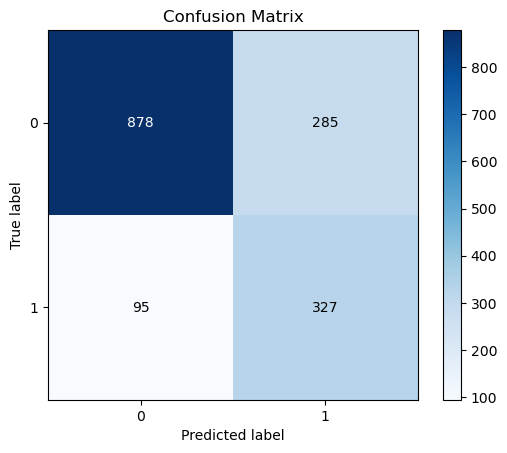

In [27]:
# Instancia e Treina o modelo
lr = LogisticRegression(random_state=42).fit(X_over, y_over)

# Predict nos dados Treino
y_pred_train = lr.predict(X_over)

print('Treino: ')
print('ROC AUC:', roc_auc_score(y_over, y_pred_train))
print('Recall:', recall_score(y_over, y_pred_train))

# Predict nos dados Validação
y_pred_valid = lr.predict(X_val_scaled)

print('\nValidação: ')
print('ROC AUC:', roc_auc_score(y_val, y_pred_valid))
print('Recall:', recall_score(y_val, y_pred_valid))

# Matriz de Confusão
skplt.metrics.plot_confusion_matrix(y_val, y_pred_valid, normalize=False);

##### RandomForest

Treino: 
ROC AUC: 0.8372526527100659
Recall: 0.8890163464295956

Validação: 
ROC AUC: 0.7552140851613535
Recall: 0.7511848341232228


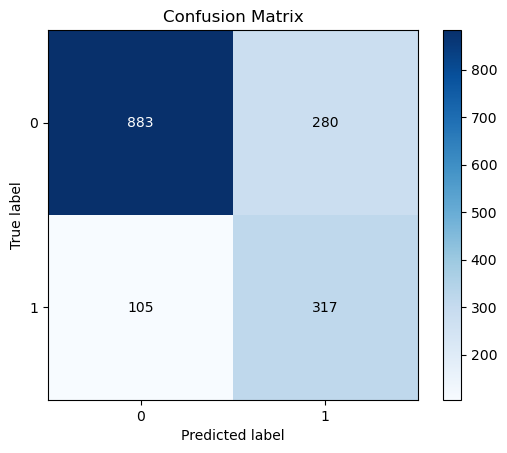

In [28]:
# Instancia e Treina o modelo
rf = RandomForestClassifier(n_estimators=500, max_depth=8, random_state=42).fit(X_over, y_over)

# Predict nos dados Treino
y_pred_train = rf.predict(X_over)

print('Treino: ')
print('ROC AUC:', roc_auc_score(y_over, y_pred_train))
print('Recall:', recall_score(y_over, y_pred_train))

# Predict nos dados Validação
y_pred_valid = rf.predict(X_val_scaled)

print('\nValidação: ')
print('ROC AUC:', roc_auc_score(y_val, y_pred_valid))
print('Recall:', recall_score(y_val, y_pred_valid))

# Matriz de Confusão
skplt.metrics.plot_confusion_matrix(y_val, y_pred_valid, normalize=False);

##### Suport Vector Machines

Treino: 
ROC AUC: 0.8200458847146544
Recall: 0.8709492400344135

Validação: 
ROC AUC: 0.7583488526567588
Recall: 0.7677725118483413


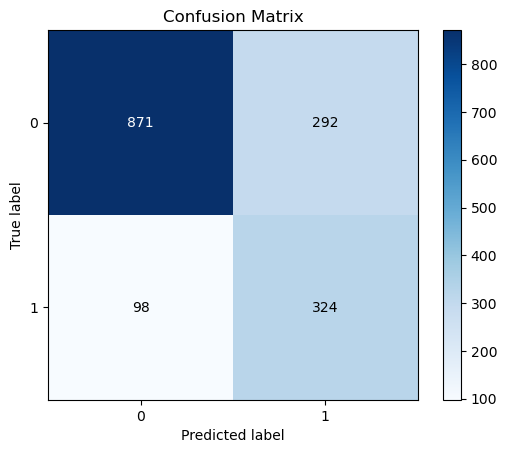

In [29]:
# Instancia e Treina o modelo
svc = SVC(random_state=42).fit(X_over, y_over)

# Predict nos dados Treino
y_pred_train = svc.predict(X_over)

print('Treino: ')
print('ROC AUC:', roc_auc_score(y_over, y_pred_train))
print('Recall:', recall_score(y_over, y_pred_train))

# Predict nos dados Validação
y_pred_valid = svc.predict(X_val_scaled)

print('\nValidação: ')
print('ROC AUC:', roc_auc_score(y_val, y_pred_valid))
print('Recall:', recall_score(y_val, y_pred_valid))

# Matriz de Confusão
skplt.metrics.plot_confusion_matrix(y_val, y_pred_valid, normalize=False);

#### Random UnderSampling

In [30]:
rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X_train_scaled, y_train)

print('Normal:', y_under.value_counts()[0], '/', round(y_under.value_counts()[0] / len(y_under) * 100, 2),'% do dataset')
print('Fraude:', y_under.value_counts()[1], '/', round(y_under.value_counts()[1] / len(y_under) * 100, 2),'% do dataset')

Normal: 1267 / 50.0 % do dataset
Fraude: 1267 / 50.0 % do dataset


##### Regressão Logistica

Treino: 
ROC AUC: 0.771112865035517
Recall: 0.8074191002367798

Validação: 
ROC AUC: 0.7712669065539766
Recall: 0.7867298578199052


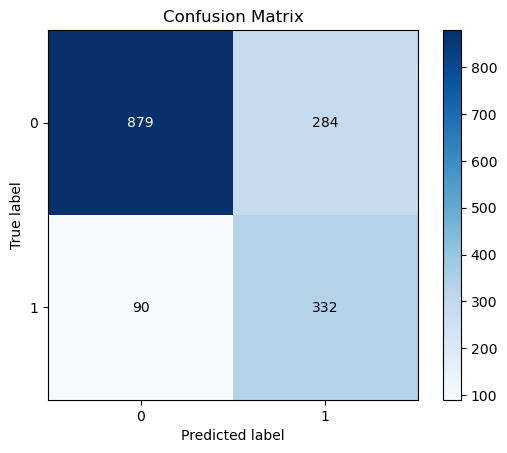

In [31]:
# Instancia e Treina o modelo
lr = LogisticRegression(random_state=42).fit(X_under, y_under)

# Predict nos dados Treino
y_pred_train = lr.predict(X_under)

print('Treino: ')
print('ROC AUC:', roc_auc_score(y_under, y_pred_train))
print('Recall:', recall_score(y_under, y_pred_train))

# Predict nos dados Validação
y_pred_valid = lr.predict(X_val_scaled)

print('\nValidação: ')
print('ROC AUC:', roc_auc_score(y_val, y_pred_valid))
print('Recall:', recall_score(y_val, y_pred_valid))

# Matriz de Confusão
skplt.metrics.plot_confusion_matrix(y_val, y_pred_valid, normalize=False);

##### RandomForest

Treino: 
ROC AUC: 0.8397790055248617
Recall: 0.8839779005524862

Validação: 
ROC AUC: 0.7584741618546577
Recall: 0.7843601895734598


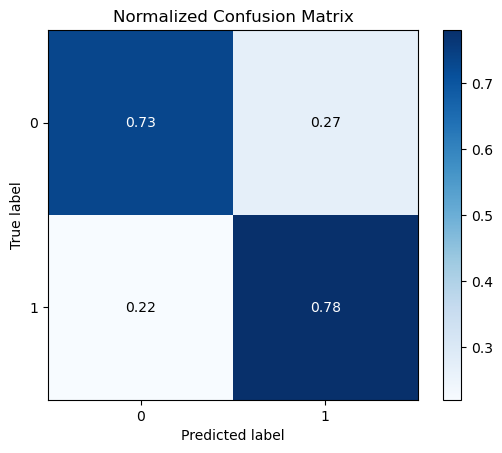

In [32]:
# Instancia e Treina o modelo
rf = RandomForestClassifier(n_estimators=500, max_depth=8, random_state=42).fit(X_under, y_under)

# Predict nos dados Treino
y_pred_train = rf.predict(X_under)

print('Treino: ')
print('ROC AUC:', roc_auc_score(y_under, y_pred_train))
print('Recall:', recall_score(y_under, y_pred_train))

# Predict nos dados Validação
y_pred_valid = rf.predict(X_val_scaled)

print('\nValidação: ')
print('ROC AUC:', roc_auc_score(y_val, y_pred_valid))
print('Recall:', recall_score(y_val, y_pred_valid))

# Matriz de Confusão
skplt.metrics.plot_confusion_matrix(y_val, y_pred_valid, normalize=True);

##### Suport Vector Machine

Treino: 
ROC AUC: 0.7940015785319654
Recall: 0.8303078137332282

Validação: 
ROC AUC: 0.7497402126385022
Recall: 0.7582938388625592


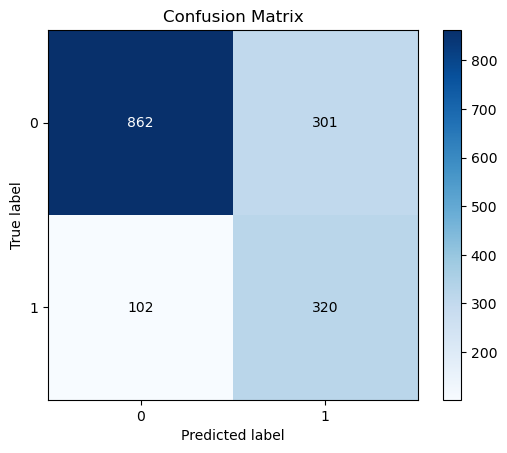

In [33]:
# Instancia e Treina o modelo
svc = SVC(random_state=42).fit(X_under, y_under)

# Predict nos dados Treino
y_pred_train = svc.predict(X_under)

print('Treino: ')
print('ROC AUC:', roc_auc_score(y_under, y_pred_train))
print('Recall:', recall_score(y_under, y_pred_train))

# Predict nos dados Validação
y_pred_valid = svc.predict(X_val_scaled)

print('\nValidação: ')
print('ROC AUC:', roc_auc_score(y_val, y_pred_valid))
print('Recall:', recall_score(y_val, y_pred_valid))

# Matriz de Confusão
skplt.metrics.plot_confusion_matrix(y_val, y_pred_valid, normalize=False);

## Análise


* O modelo e a técnica que apresentou o maior número de True Positives: RandomForest com UnderSampling - 331 acertos<br>
* O modelo e a técnica que apresentou o menor número nos falsos negativos: RandomForest com UnderSampling - 91 erros<br>
* O modelo RandomForest com a técnica de UnderSampling apresentou o melhor resultado para a métrica de `Recall`

## Otimização de Hyperparametros com GridSearchCV

In [34]:
kf = StratifiedKFold(n_splits=3, shuffle=False)

params = {
    'n_estimators': [100, 200, 500, 1000, 1500, 2000],
    'max_depth': [4, 6, 8, 10, 12, 15],
    'random_state' : [42]
}

grid_rf = GridSearchCV(rf, param_grid=params, cv=kf, scoring='recall').fit(X_under, y_under)

print('Melhores parametros: ', grid_rf.best_params_)
print('Melhor score: ', grid_rf.best_score_)

y_pred = grid_rf.best_estimator_.predict(X_val_scaled)

# Recall
print('Recall:', recall_score(y_val, y_pred))

Melhores parametros:  {'max_depth': 6, 'n_estimators': 500, 'random_state': 42}
Melhor score:  0.8224242695857095
Recall: 0.7843601895734598


#### Observação

Score nos dados de treino:
- Modelo sem a otimização: 0.88
- Modelo com a otimização: 0.82

Score nos dados de validação:
- Modelo sem a otimização: 0.78
- Modelo com a otimização: 0.78

Podemos observar que o modelo melhorou o seu aprendizado nos dados de treino, reduzindo o sobreajuste *(overfitting)*. Com relação ao score nos dados de validação não tivemos uma melhora, o que pode indicar que com esses dados de entrada o modelo não consegue um melhor desempenho.

## Feature Selection

O objetivo aqui é tentar selecionar as melhores variáveis com a finalidade de melhorar o score do modelo nos dados de validação.

In [35]:
feature_importances = pd.DataFrame(grid_rf.best_estimator_.feature_importances_, index=X_under.columns, columns=['importance']).sort_values('importance', ascending=False)
feature_importances[:15]

,importance
tenure,0.206507
TotalCharges,0.129247
Contract_Two year,0.127565
InternetService_Fiber optic,0.082254
MonthlyCharges,0.069616
PaymentMethod_Electronic check,0.060226
Contract_One year,0.045387
OnlineSecurity_Yes,0.037403
TechSupport_Yes,0.025054
StreamingMovies_No internet service,0.019543


Para a seleção das variáveis vou utilizar a técnica de Informação mútua *(mutual_info_classif)*

A informação mútua (MI) entre duas variáveis aleatórias é um valor não negativo, que mede a dependência entre as variáveis. É igual a zero se e somente se duas variáveis aleatórias são independentes, e valores mais altos significam maior dependência.

A função depende de métodos não paramétricos baseados na estimativa de entropia a partir das distâncias dos k vizinhos mais próximos. Como refere https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.mutual_info_classif.html#r50b872b699c4-4

In [36]:
# random seed
np.random.seed(42)

# seleciona as 15 vairáveis
select_new_vars = SelectKBest(mutual_info_classif, k=25)
select_new_vars.fit(X_under, y_under)
new_vars = list(X_under.columns[select_new_vars.get_support()])
new_vars

['SeniorCitizen',
 'tenure',
 'MonthlyCharges',
 'TotalCharges',
 'Partner_Yes',
 'Dependents_Yes',
 'PhoneService_Yes',
 'MultipleLines_No phone service',
 'MultipleLines_Yes',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_No internet service',
 'OnlineSecurity_Yes',
 'OnlineBackup_No internet service',
 'DeviceProtection_No internet service',
 'TechSupport_No internet service',
 'TechSupport_Yes',
 'StreamingTV_No internet service',
 'StreamingTV_Yes',
 'StreamingMovies_No internet service',
 'Contract_One year',
 'Contract_Two year',
 'PaperlessBilling_Yes',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check']

Agora preciso atualizar meu *dataset* com as variáveis que foram selecionadas.

In [37]:
# preserva os dados do dataset original
X_under_new = X_under.copy()
X_val_new   = X_val_scaled.copy()

# dataset de treino
X_under_new = X_under_new[new_vars]
print(X_under_new.shape)

# dataset de validação
X_val_new = X_val_new[new_vars]
print(X_val_new.shape)

# visualiza as primerias entradas
X_under_new.head()

(2534, 25)
(1585, 25)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check
253,0.0,0.055556,0.122378,0.295559,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2963,0.0,1.000000,0.879620,0.978995,1.0,0.0,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
4417,0.0,0.625000,0.005994,0.622380,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
260,0.0,0.347222,0.017982,0.538273,1.0,1.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1487,0.0,0.083333,0.014486,0.310265,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [38]:
kf = StratifiedKFold(n_splits=3, shuffle=False)

params = {
    'n_estimators': [100, 200, 500, 1000, 1500, 2000],
    'max_depth': [4, 6, 8, 10, 12, 15],
    'random_state' : [42]
}

grid_rf = GridSearchCV(rf, param_grid=params, cv=kf, scoring='recall').fit(X_under_new, y_under)

print('Melhores parametros: ', grid_rf.best_params_)
print('Melhor score: ', grid_rf.best_score_)

y_pred = grid_rf.best_estimator_.predict(X_val_new)

# Recall
print('Recall:', recall_score(y_val, y_pred))

Melhores parametros:  {'max_depth': 4, 'n_estimators': 2000, 'random_state': 42}
Melhor score:  0.824782733726971
Recall: 0.8009478672985783


Otimo. O score nos dados de validação teve uma melhora.

## Fazendo Previsões no Conjunto de Teste

No começo do projeto, realizamos um split nos dados para que tivéssemos 3 conjuntos: Um de treino, um de validação e um de teste.

Agora que já exploramos e preparamos os dados, instaciamos o modelo e fizemos previsões no conjunto de validação, é hora de descobrirmos o potencial desse modelo com os dados de teste.

O que faremos é apenas utilizar o modelo que treinamos com um novo conjunto. Mas, para que os resultados sejam justos, precisamos fazer com que os novos dados estejam nas mesmas condições daqueles que o nosso modelo espera.

In [39]:
# Mapeamento da variável target, variáveis dummies e normalização
test_clean = test.copy()

# Dropa a variável customerID
test_clean = test_clean.drop('customerID', axis=1)

# converte as strings de TotalCharges para float
test_clean['TotalCharges'] = test_clean['TotalCharges'].apply(converter_str_float)

# substitui os dados ausentes pelo valor da mediana
test_clean['TotalCharges'] = test_clean['TotalCharges'].fillna(median_values.loc['Two year'])

# mapeamento da variável Churn
test_clean['Churn'] = test_clean['Churn'].map({'No': 0, 'Yes': 1})

# transformação das variáveis categóricas em numéricas
test_clean = pd.get_dummies(test_clean, drop_first=True, dtype=int)

# normalização dos dados
test_clean_scaled = pd.DataFrame(mms.fit_transform(test_clean), columns=test_clean.columns)

# verifica as primeiras entradas
test_clean_scaled.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,0.263889,0.397206,0.122399,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.833333,0.980040,0.838375,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0
2,0.0,0.180556,0.534431,0.107923,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.0,0.013889,0.020459,0.000197,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.0,0.763889,0.592315,0.506505,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


Agora basta seprar entre X e y, e fazer nossas previsões.

In [40]:
# separa variáveis entre X e y
X_test = test_clean_scaled.drop('Churn', axis=1)
y_test = test_clean_scaled['Churn']

# filtra pelas 25 variaveis que foram selecionadas
X_test = X_test[new_vars]
X_test.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check
0,0.0,0.263889,0.397206,0.122399,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,0.833333,0.980040,0.838375,0.0,0.0,1.0,0.0,1.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
2,0.0,0.180556,0.534431,0.107923,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,0.0,0.013889,0.020459,0.000197,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.763889,0.592315,0.506505,1.0,0.0,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


Pronto! Com nossas previsões feitas, é hora de visualizar os resultados.

In [41]:
# realiza as previsões em cima dos dados de teste
y_pred = grid_rf.best_estimator_.predict(X_test)

#### Matriz de Confusão

Recall: 0.7944444444444444


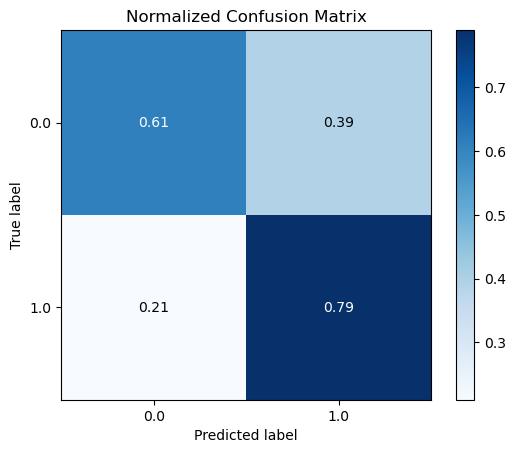

In [42]:
# Recall
print('Recall:', recall_score(y_test, y_pred))

# Matriz de Confusão
skplt.metrics.plot_confusion_matrix(y_test, y_pred, normalize=True);

#### ROC AUC

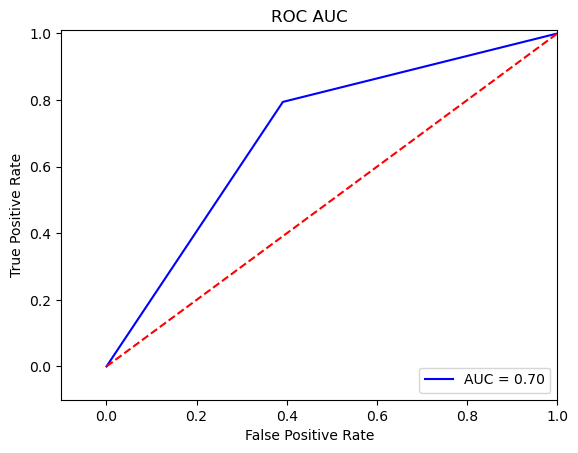

In [43]:
# previsões em cima dos dados de validação
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.title('ROC AUC')
plt.plot(fpr, tpr, 'b',label='AUC = %0.2f'% roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([-0.1,1.0])
plt.ylim([-0.1,1.01])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

## Melhorias

* Nosso modelo *Random Forest* apresentou o melhor desempenho, por pertencer à classe das árvores de decisões poderíamos treinar com modelos mais avançados baseados desse tipo, como, XGBoost, LightGBM, entre outros
* Através de alguns estudos poderimos aplicar a técnica de Feature Engineering

## Conclusão

Por volta de 80% das vezes que nosso cliente iria cancelar, o modelo conseguiu identificar, podendo assim ser tomada decisões para tentar manter o cliente na empresa.

## Referencias

https://cursos.sigmoidal.ai/

https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.mutual_info_classif.html#r50b872b699c4-4

https://imbalanced-learn.org/stable/user_guide.html

https://github.com/krishnaik06/Complete-Feature-Selection/blob/master/3-%20Information%20gain%20-%20mutual%20information%20In%20Classification.ipynb

https://opendatascience.com/transforming-skewed-data-for-machine-learning/